# COVID19 BIMCV Classifier
## CPSC483 CSUF

# Imports

In [2]:
import os
import pandas as pd
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import json
import matplotlib.pyplot as plt
import matplotlib.image as img
import tarfile
import re
import shutil
import concurrent.futures
from concurrent.futures import ProcessPoolExecutor
import aiohttp
import aiofiles
import asyncio
import requests
import xml.etree.ElementTree as ET

IMAGE_TYPE_IDENTIFIER = '00280004'
# BASE_DIR = "/Volumes/Samsung USB"
BASE_DIR = "."
DRIVE_FOLDER = "/content/drive/MyDrive/Skool/CPSC483 Project/"

In [ ]:
# Configuration
NEGATIVE_TOKEN = "BIMCV-COVID19-cIter_1_2-Negative"
POSITIVE_TOKEN = "BIMCV-COVID19-cIter_1_2_3"
BASE_URL = "https://b2drop.bsc.es/public.php/webdav/"

# Preprocessing

In [3]:
# 1. List files in the share
def list_files(base_url, share_token):
    # Nextcloud public WebDAV requires the token as the username
    response = requests.request(
        "PROPFIND",
        base_url,
        auth=(share_token, ""),
        headers={"Depth": "1"}
    )

    if response.status_code == 207:
        # Parse XML response to find file paths
        tree = ET.fromstring(response.content)
        files = []
        for prop in tree.findall(".//{DAV:}response"):
            href = prop.find("{DAV:}href").text
            filename = href.split('/')[-1]
            if filename and "subjects" in filename and filename.endswith(".tar.gz"):
                files.append(filename)
        return sorted(files)
    else:
        print(f"Failed to list files: {response.status_code}")
        return []

async def download_file_async(session, base_url, share_token, filename):
    url = f"{base_url}{filename}"
    auth = aiohttp.BasicAuth(share_token, "")
    async with session.get(url, auth=auth) as response:
        response.raise_for_status()
        content_length = response.headers.get('Content-Length')
        total_size = int(content_length) if content_length else None

        async with aiofiles.open(os.path.join(DRIVE_FOLDER, filename), mode='wb') as f:
            with tqdm(total=total_size, unit='B', unit_scale=True, desc="Downloading " + filename + f" ({(total_size/1024/1024/1024 if total_size else 0):.2f}GB)") as pbar:
                async for chunk in response.content.iter_chunked(1024*1024):
                    await f.write(chunk)
                    pbar.update(len(chunk))
    return filename

async def download_missing():
  negative_files = list_files(BASE_URL, NEGATIVE_TOKEN)[:20]
  positive_files = list_files(BASE_URL, POSITIVE_TOKEN)[:20]

  already_have = set([f for f in os.listdir(DRIVE_FOLDER) if f.endswith(".tar.gz")])
  print("Already have:", already_have)

  negative_files = [f for f in negative_files if f not in already_have]
  positive_files = [f for f in positive_files if f not in already_have]
  print("Negative files:",  negative_files[:3], "...")
  print("Positive files:",  positive_files[:3], "...")

  print(f"Will download {len(negative_files)+len(positive_files)} files.")

  # Disable the total timeout for large files
  timeout = aiohttp.ClientTimeout(total=None)

  for f in negative_files:
    async with aiohttp.ClientSession(timeout=timeout) as session:
      await download_file_async(session, BASE_URL, NEGATIVE_TOKEN, f)
  for f in positive_files:
    async with aiohttp.ClientSession(timeout=timeout) as session:
      await download_file_async(session, BASE_URL, POSITIVE_TOKEN, f)

def tar_extract(filename, out_folder):
  if not filename.endswith(".tar.gz"): return
  with tarfile.open(filename, 'r:gz') as tar:
    tar.extractall(path=out_folder, filter='data', )


def process_extracted(start_dir, label):
    print(f"processing {start_dir}")
    tasks = []
    without_json = 0

    # 1. Gather all tasks
    for root, _, files in os.walk(start_dir):
        for f in files:
            if f.endswith(".png") and not f.startswith("."):
                json_file = os.path.join(root, f.replace("png", "json"))
                if not os.path.exists(json_file):
                    without_json += 1
                    continue
                tasks.append((root, f, json_file, "images"))

    print(f"gathered {len(tasks)} tasks")

    with_json = len(tasks)
    print(f"Images with JSON metadata: {with_json}")
    print(f"Images without JSON metadata: {without_json}")

    results = []
    # 2. Process tasks concurrently
    if tasks:
        with ProcessPoolExecutor() as executor:
            futures = [executor.submit(process_single_image, *task) for task in tasks]
            for future in tqdm(concurrent.futures.as_completed(futures), total=len(futures), desc=f"Processing {start_dir}", unit=" img"):
                res = future.result()
                if res:
                    res['label'] = label
                    results.append(res)

    return pd.DataFrame(results) if results else pd.DataFrame(columns=['subject', 'image_path', 'image_type', 'session', 'label'])

# Optimized helper to process a single image (to be used with ProcessPool)
def process_single_image(root, f, json_file, target_dir):
    try:
        with open(json_file) as file:
            metadata = json.load(file)
            image_type = metadata[IMAGE_TYPE_IDENTIFIER]['Value'][0]
        subject = re.search(r'sub-S\d+', f).group()
        session = re.search(r'ses-E\d+', f).group()
        image_name = f"{subject}_{session}_{image_type}.png"
        with Image.open(os.path.join(root, f)) as image:
            resized_image = image.resize((1024, 1024))
            resized_image.save(os.path.join(target_dir, image_name))
        return {'subject': subject, 'image_path': os.path.join(target_dir, image_name), 'image_type': image_type, 'session': session}
    except Exception as e:
        return None

def process():
  posi = process_extracted(os.path.join(DRIVE_FOLDER, "covid19_posi"), True)
  neg = process_extracted(os.path.join(DRIVE_FOLDER, "covid19_neg"), False)
  return pd.concat([posi, neg])

In [8]:
df = pd.read_csv("dataset/data.csv")
df['image_path'] = df['image_path'].apply(lambda x: f"dataset/{x}")
df.head()

,Unnamed: 0,subject,image_path,image_type,session,label
0,0,sub-S330274,dataset/images/sub-S330274_ses-E61728_MONOCHRO...,MONOCHROME2,ses-E61728,True
1,1,sub-S329184,dataset/images/sub-S329184_ses-E68374_MONOCHRO...,MONOCHROME2,ses-E68374,True
2,2,sub-S329184,dataset/images/sub-S329184_ses-E59042_MONOCHRO...,MONOCHROME2,ses-E59042,True
3,3,sub-S330274,dataset/images/sub-S330274_ses-E61731_MONOCHRO...,MONOCHROME2,ses-E61731,True
4,4,sub-S330274,dataset/images/sub-S330274_ses-E61728_MONOCHRO...,MONOCHROME2,ses-E61728,True


In [4]:
if os.path.exists("images"):
  print("removing images folder...")
  shutil.rmtree("images")
print("creating images folder...")
os.mkdir("images")
print("processing...")
df = process()

print(df.shape)
df.head()

creating images folder...
processing...
processing /content/drive/MyDrive/Skool/CPSC483 Project/covid19_posi
gathered 2393 tasks
Images with JSON metadata: 2393
Images without JSON metadata: 282


Processing /content/drive/MyDrive/Skool/CPSC483 Project/covid19_posi: 100%|██████████| 2393/2393 [01:58<00:00, 20.15 img/s]


processing /content/drive/MyDrive/Skool/CPSC483 Project/covid19_neg
gathered 1489 tasks
Images with JSON metadata: 1489
Images without JSON metadata: 162


Processing /content/drive/MyDrive/Skool/CPSC483 Project/covid19_neg: 100%|██████████| 1489/1489 [01:08<00:00, 21.85 img/s]

(3882, 5)


,subject,image_path,image_type,session,label
0,sub-S330274,images/sub-S330274_ses-E61728_MONOCHROME2.png,MONOCHROME2,ses-E61728,True
1,sub-S329184,images/sub-S329184_ses-E68374_MONOCHROME2.png,MONOCHROME2,ses-E68374,True
2,sub-S329184,images/sub-S329184_ses-E59042_MONOCHROME2.png,MONOCHROME2,ses-E59042,True
3,sub-S330274,images/sub-S330274_ses-E61731_MONOCHROME2.png,MONOCHROME2,ses-E61731,True
4,sub-S330274,images/sub-S330274_ses-E61728_MONOCHROME2.png,MONOCHROME2,ses-E61728,True


In [10]:
df.reset_index(drop=True, inplace=True)
# Validate image paths in the DataFrame
valid_indices = []
problematic_image_paths = []
for idx, row in tqdm(df.iterrows(), total=len(df), desc="Validating images in DataFrame"):
    img_path = os.path.relpath(row['image_path'], './')
    try:
        # Attempt to open the image and verify its integrity
        with Image.open(img_path) as pil_img:
            pil_img.verify() # Verify that it is an image
        valid_indices.append(idx)
    except Exception as e:
        problematic_image_paths.append((img_path, str(e)))
        # Optionally, remove the problematic file if it exists
        if os.path.exists(img_path):
            os.remove(img_path)

if problematic_image_paths:
    print(f"Found {len(problematic_image_paths)} problematic images. Filtering them out.")
    for path, error_msg in problematic_image_paths[:5]: # Print first 5 errors
        print(f"  {path}: {error_msg}")
    if len(problematic_image_paths) > 5:
        print("... (truncated)")
    df = df.loc[valid_indices].reset_index(drop=True)
    print(f"Filtered DataFrame to {len(df)} valid images.")
else:
    print("All images in DataFrame are valid.")

Validating images in DataFrame: 100%|██████████| 3723/3723 [00:02<00:00, 1426.54it/s] 

Found 1533 problematic images. Filtering them out.
  dataset/images/sub-S330274_ses-E61728_MONOCHROME2.png: [Errno 2] No such file or directory: 'dataset/images/sub-S330274_ses-E61728_MONOCHROME2.png'
  dataset/images/sub-S329184_ses-E68374_MONOCHROME2.png: [Errno 2] No such file or directory: 'dataset/images/sub-S329184_ses-E68374_MONOCHROME2.png'
  dataset/images/sub-S329184_ses-E59042_MONOCHROME2.png: [Errno 2] No such file or directory: 'dataset/images/sub-S329184_ses-E59042_MONOCHROME2.png'
  dataset/images/sub-S330274_ses-E61731_MONOCHROME2.png: [Errno 2] No such file or directory: 'dataset/images/sub-S330274_ses-E61731_MONOCHROME2.png'
  dataset/images/sub-S330274_ses-E61728_MONOCHROME2.png: [Errno 2] No such file or directory: 'dataset/images/sub-S330274_ses-E61728_MONOCHROME2.png'
... (truncated)
Filtered DataFrame to 2190 valid images.


In [6]:
df.to_csv("data.csv")

# Preview Data

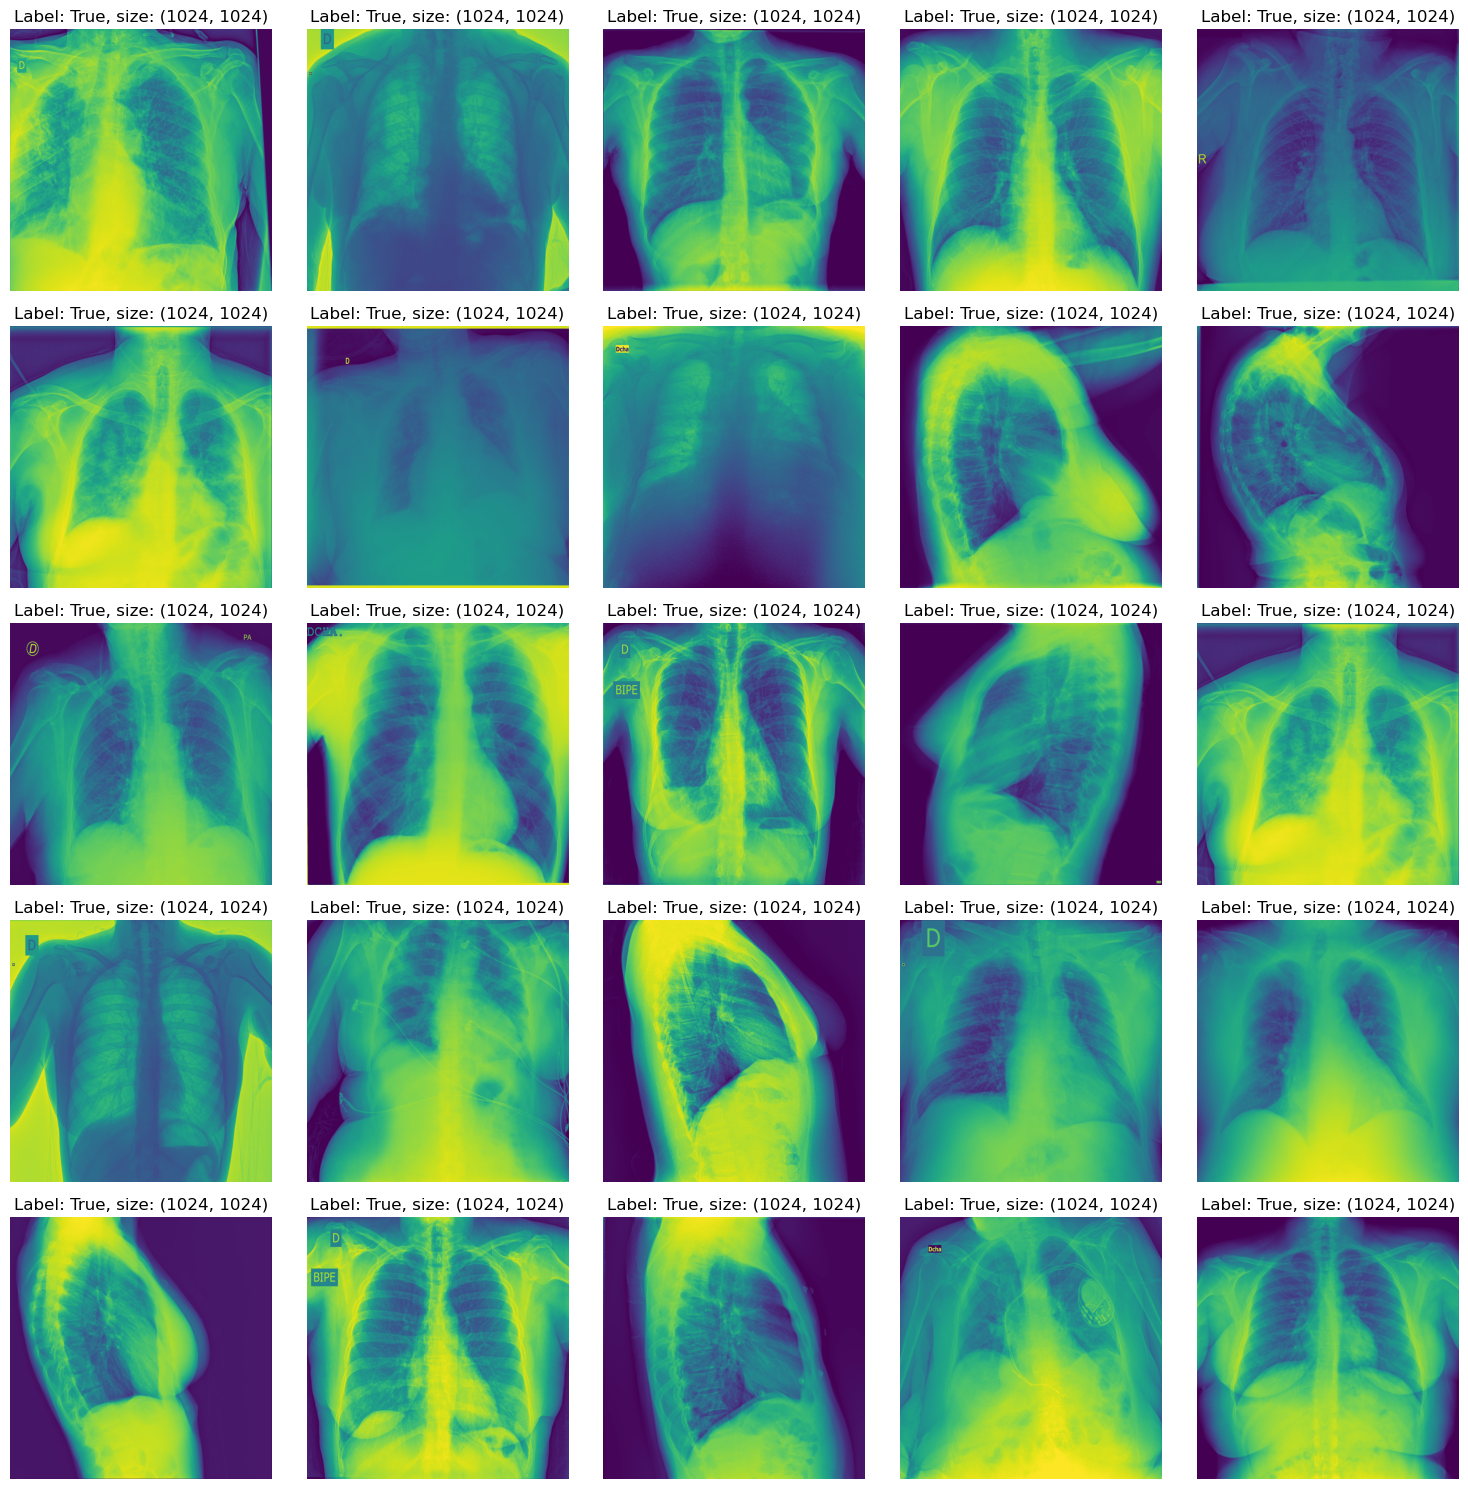

In [11]:
# preview 25 images from dataframe and plot them in a 5x5 grid
fig, axes = plt.subplots(5, 5, figsize=(15, 15))
for i, ax in enumerate(axes.flatten()):
    if i >= len(df):
        break
    image_path = df.sample(n=1).iloc[0]['image_path']
    image = img.imread(image_path)
    ax.imshow(image)
    ax.set_title(f"Label: {df.iloc[i]['label']}, size: {image.shape}")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [12]:
# get class imbalance
print(df['label'].value_counts())
num_neg = df['label'].value_counts()[False]
num_pos = df['label'].value_counts()[True]
num_neg, num_pos

label
False    1282
True      908
Name: count, dtype: int64


(np.int64(1282), np.int64(908))

# Dataset Loader

In [13]:
class ChestXRayDataset(Dataset):
    def __init__(self, df, base_dir, transform=None):
        """
        Args:
            df:        DataFrame with 'image_path', 'label', 'image_type' columns
            base_dir:  Root directory where your images live (replaces the './')
            transform: torchvision transforms to apply
        """
        self.df = df.reset_index(drop=True)
        self.base_dir = base_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Build absolute path — replace leading './' with your base_dir
        rel_path = os.path.relpath(row['image_path'], './')
        img_path = os.path.join(self.base_dir, rel_path)

        # Load image as grayscale (X-rays are single channel)
        img = Image.open(img_path).convert('L')

        # Handle MONOCHROME1 (inverted) vs MONOCHROME2 (normal)
        # MONOCHROME1: 0=white, max=black — needs inversion
        if row['image_type'] == 'MONOCHROME1':
            img = Image.fromarray(np.invert(np.array(img)))

        if self.transform:
            img = self.transform(img)

        label = torch.tensor(int(row['label']), dtype=torch.float32)
        return img, label

In [23]:
import cv2

class ChestXRayDatasetCLAHE(Dataset):
    def __init__(self, df, base_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.base_dir = base_dir
        self.transform = transform
        # Initialize CLAHE
        self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        rel_path = os.path.relpath(row['image_path'], './')
        img_path = os.path.join(self.base_dir, rel_path)

        # Load image in grayscale using OpenCV
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            # Fallback if cv2 fails for some reason
            img = np.array(Image.open(img_path).convert('L'))

        # Handle MONOCHROME1 (inverted)
        if row['image_type'] == 'MONOCHROME1':
            img = cv2.bitwise_not(img)

        # Apply CLAHE to enhance contrast
        img = self.clahe.apply(img)

        # Convert back to PIL Image so torchvision transforms work
        img = Image.fromarray(img)

        if self.transform:
            img = self.transform(img)

        label = torch.tensor(int(row['label']), dtype=torch.float32)
        return img, label

# Transforms for training and validation sets

In [24]:
train_transforms = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),                        # converts to [0, 1]
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),  # convert grayscale to 3 channels
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet normalization
])

val_transforms = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),  # convert grayscale to 3 channels
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet normalization
])

# Prepare training and validation sets

In [25]:
from sklearn.model_selection import StratifiedGroupKFold

# Ensure subjects are consistently typed
df['subject'] = df['subject'].astype(str)
df['label'] = df['label'].astype(int)

# First split: separate out the test set (20%)
sgkf_test = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_val_idx, test_idx = next(sgkf_test.split(df, df['label'], groups=df['subject']))

train_val_df = df.iloc[train_val_idx].reset_index(drop=True)
test_df      = df.iloc[test_idx].reset_index(drop=True)

# Second split: separate the remaining 80% into Train (75% of 80% = 60%) and Val (25% of 80% = 20%)
sgkf_val = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=42)
train_idx, val_idx = next(sgkf_val.split(train_val_df, train_val_df['label'], groups=train_val_df['subject']))

train_df = train_val_df.iloc[train_idx].reset_index(drop=True)
val_df   = train_val_df.iloc[val_idx].reset_index(drop=True)

print(f"Train: {len(train_df)} images ({train_df['label'].sum()} positive)")
print(f"Val:   {len(val_df)} images ({val_df['label'].sum()} positive)")
print(f"Test:  {len(test_df)} images ({test_df['label'].sum()} positive)")

Train: 1314 images (545 positive)
Val:   438 images (182 positive)
Test:  438 images (181 positive)


# Prepare Data Loaders

In [45]:
train_dataset = ChestXRayDatasetCLAHE(train_df, '.', transform=train_transforms)
val_dataset   = ChestXRayDatasetCLAHE(val_df,   '.', transform=val_transforms)
test_dataset  = ChestXRayDatasetCLAHE(test_df,  '.', transform=val_transforms)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    # num_workers=2,
    # pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    # num_workers=2,
    # pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    # num_workers=2,
    # pin_memory=True
)

# Model

In [46]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # compute standard BCE loss with logits
        BCE_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')

        # pt is the probability of the true class
        pt = torch.exp(-BCE_loss)

        # compute focal loss
        F_loss = self.alpha * (1-pt)**self.gamma * BCE_loss

        if self.reduction == 'mean':
            return torch.mean(F_loss)
        elif self.reduction == 'sum':
            return torch.sum(F_loss)
        else:
            return F_loss

In [47]:
model = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)

# Freeze the backbone initially to allow the new head to warm up.
# for param in model.parameters():
    # param.requires_grad = False

# Replace classifier with a small MLP head (ResNet uses 'fc' instead of 'classifier')
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128, 1),
)
# The new classifier parameters have requires_grad=True by default.

# Training Structure

In [ ]:
%pip install torchinfo
from torchinfo import summary

In [48]:
device    = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.mps.is_available() else 'cpu')
model     = model.to(device)

# Verify model is actually on the correct device
print('device:', device)
print('model device:', next(model.parameters()).device)

# criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([num_neg/num_pos], device=device))
criterion = FocalLoss(alpha=1, gamma=2, reduction='mean')

# Differential learning rates: 1e-5 for backbone, 1e-3 for the new head
classifier_params = list(model.fc.parameters())
feature_params = [p for n, p in model.named_parameters() if not n.startswith('fc')]

optimizer = torch.optim.Adam([
    {'params': feature_params, 'lr': 1e-5},
    {'params': classifier_params, 'lr': 1e-3}
], weight_decay=1e-3) # Increased weight decay to combat overfitting

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0, 0
    with tqdm(total=len(loader), desc='training') as pbar:
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device).unsqueeze(1)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == labels).sum().item()
            pbar.update()
    return total_loss / len(loader), correct / len(loader.dataset)

def val_epoch(model, loader, criterion, desc):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        with tqdm(total=len(loader), desc=desc) as pbar:
            for imgs, labels in loader:
                imgs, labels = imgs.to(device), labels.to(device).unsqueeze(1)
                outputs = model(imgs)
                total_loss += criterion(outputs, labels).item()
                preds = (torch.sigmoid(outputs) > 0.5).float()
                correct += (preds == labels).sum().item()
                pbar.update()
    return total_loss / len(loader), correct / len(loader.dataset)

summary(model, input_size=(8, 3, 512, 512), device=device)


device: mps
model device: mps:0


Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [8, 1]                    --
├─Conv2d: 1-1                            [8, 64, 256, 256]         9,408
├─BatchNorm2d: 1-2                       [8, 64, 256, 256]         128
├─ReLU: 1-3                              [8, 64, 256, 256]         --
├─MaxPool2d: 1-4                         [8, 64, 128, 128]         --
├─Sequential: 1-5                        [8, 64, 128, 128]         --
│    └─BasicBlock: 2-1                   [8, 64, 128, 128]         --
│    │    └─Conv2d: 3-1                  [8, 64, 128, 128]         36,864
│    │    └─BatchNorm2d: 3-2             [8, 64, 128, 128]         128
│    │    └─ReLU: 3-3                    [8, 64, 128, 128]         --
│    │    └─Conv2d: 3-4                  [8, 64, 128, 128]         36,864
│    │    └─BatchNorm2d: 3-5             [8, 64, 128, 128]         128
│    │    └─ReLU: 3-6                    [8, 64, 128, 128]         --
│

# Train

In [49]:
from colorama import Fore

NUM_EPOCHS = 20
PATIENCE = 6

# Gradual unfreezing schedule (epoch index -> list of layer names to unfreeze)
unfreeze_schedule = {
    2: ['layer4'],
    4: ['layer3'],
    6: ['layer2'],
}

epochs = []
best_val_loss = float('inf')
best_model_state = None
epochs_no_improve = 0

for epoch in range(NUM_EPOCHS):
    print(f"Epoch {epoch+1:02d}")

    # # Check for gradual unfreezing
    # if epoch in unfreeze_schedule:
    #     layers_to_unfreeze = unfreeze_schedule[epoch]
    #     print(f"--> Unfreezing layers: {', '.join(layers_to_unfreeze)}")
    #     for name, param in model.named_parameters():
    #         if any(name.startswith(layer_name) for layer_name in layers_to_unfreeze):
    #             param.requires_grad = True

    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    test_loss, test_acc   = val_epoch(model, test_loader, criterion, "testing")
    val_loss, val_acc     = val_epoch(model, val_loader, criterion, "validating")

    scheduler.step(val_loss)
    epochs.append((train_loss, train_acc, val_loss, val_acc, test_loss, test_acc))
    print(f"Train - {Fore.RED}Loss: {train_loss:.4f}{Fore.RESET} | {Fore.GREEN}Acc: {train_acc:.3f}{Fore.RESET}\n"
          f"Val   - {Fore.RED}Loss: {val_loss:.4f}{Fore.RESET} | {Fore.GREEN}Acc: {val_acc:.3f}{Fore.RESET}\n"
          f"Test  - {Fore.RED}Loss: {test_loss:.4f}{Fore.RESET} | {Fore.GREEN}Acc: {test_acc:.3f}{Fore.RESET}\n"
          f"LR: {optimizer.param_groups[0]['lr']:.1e}\n")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

# Restore best model
if best_model_state:
    model.load_state_dict(best_model_state)
    print(f"\nRestored best model (val loss: {best_val_loss:.4f})")

Epoch 01


validating: 100%|██████████| 55/55 [00:13<00:00,  4.17it/s]


Train - Loss: 0.1764 | Acc: 0.575
Val   - Loss: 0.1628 | Acc: 0.642
Test  - Loss: 0.1624 | Acc: 0.660
LR: 1.0e-05

Epoch 02


training:  12%|█▏        | 19/165 [00:12<01:39,  1.47it/s]


KeyboardInterrupt: 

# Plotting Accuracy/Loss

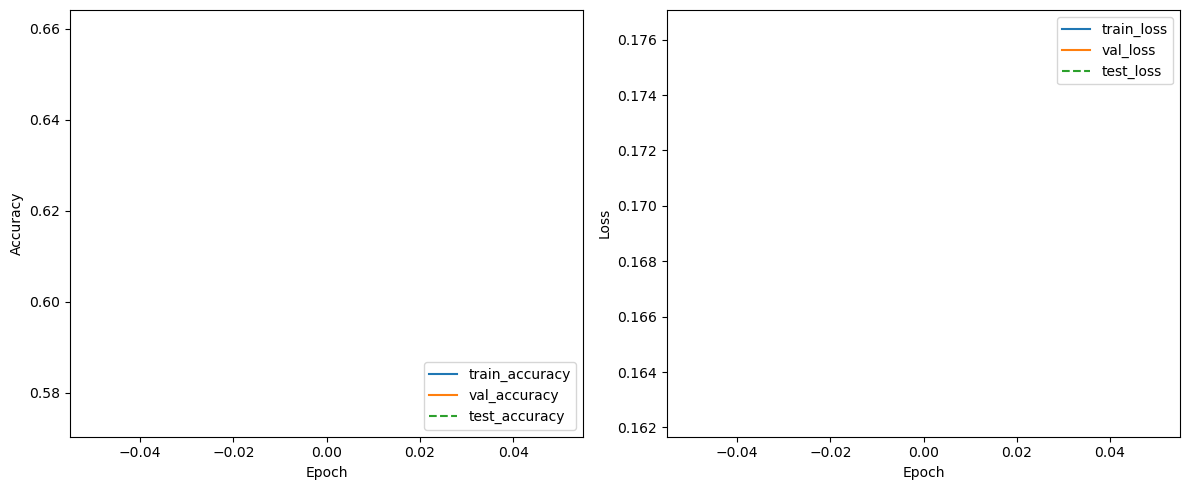

In [50]:
train_losses, train_accs, val_losses, val_accs, test_losses, test_accs = zip(*epochs)
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].plot(train_accs, label='train_accuracy')
axs[0].plot(val_accs, label='val_accuracy')
axs[0].plot(test_accs, label='test_accuracy', linestyle='--')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Accuracy')
axs[0].legend(loc='lower right')

axs[1].plot(train_losses, label='train_loss')
axs[1].plot(val_losses, label='val_loss')
axs[1].plot(test_losses, label='test_loss', linestyle='--')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Loss')
axs[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

# Evaluation Metrics

Classification Report on Test Set (Threshold: 0.5):
              precision    recall  f1-score   support

    Negative       0.58      0.64      0.61       276
    Positive       0.76      0.70      0.73       437

    accuracy                           0.68       713
   macro avg       0.67      0.67      0.67       713
weighted avg       0.69      0.68      0.68       713

AUC-ROC: 0.7783


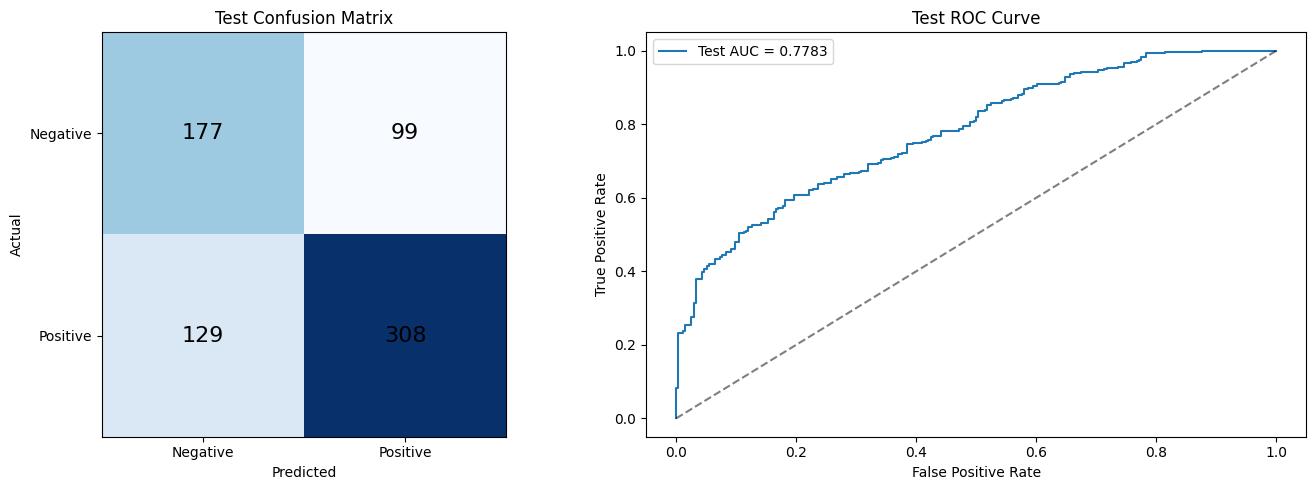

In [23]:
# Collect predictions on the TEST set
model.eval()
all_labels = []
all_probs = []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        probs = torch.sigmoid(outputs).cpu().numpy().flatten()
        all_probs.extend(probs)
        all_labels.extend(labels.numpy().flatten())

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

THRESHOLD = 0.5
all_preds = (all_probs > THRESHOLD).astype(int)

# Classification report (precision, recall, F1)
print(f"Classification Report on Test Set (Threshold: {THRESHOLD}):")
print(classification_report(all_labels, all_preds, target_names=['Negative', 'Positive']))

# AUC-ROC
auc = roc_auc_score(all_labels, all_probs)
print(f"AUC-ROC: {auc:.4f}")

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(all_labels, all_preds)
axes[0].imshow(cm, cmap='Blues')
axes[0].set_title('Test Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Negative', 'Positive'])
axes[0].set_yticklabels(['Negative', 'Positive'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=16)

# ROC curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
axes[1].plot(fpr, tpr, label=f'Test AUC = {auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Test ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()